# Carr-Madan for Option Pricing in the Heston Regime

In our current implementation (`Heston-options-calibration.ipynb`) we rely on two different integrals:  

$$
P_j(S_T>K) = \frac{1}{2} + \frac{1}{\pi} \int_0^\infty \text{Re}\left[\frac{e^{-i\omega\log(K)} \phi_j(\omega)}{i\omega}\right] d\omega
$$

For i = 1, 2   

During optimisation, we call this twice per option, for 50 options that's 100 calls, assuming 60 optimizer iterations per option during optimisation, that means 6000 calls. This currently takes about 3.5 mins for an options surface.  


An an immediate obervation is that $\phi = \phi(T)$ and does not depend on the strike $K$. This means that for each maturity, we only need to calculate the characteristic function once. Giving $C(K)$.


$$
C(K) \propto \int_0^\infty \text{Re}\left[\frac{e^{-i\omega\log(K)} \phi(\omega)}{i\omega}\right] d\omega
$$

Let $k = \ln K$, this gives the following expression for $C(k)$:


$$
C(k) \propto \int_{- \infty}^\infty e^{-i\omega k}  \cdot \frac{\phi(\omega)}{i\omega} d\omega
$$

We will define  $\frac{\phi(\omega)}{i\omega} = \hat f(\omega)$ and we can see that this expression is the inverse fourier transform of $\hat f(\omega)$. The 
call price as a function of log-strike is already the IFT of something built from $\phi$.

The immediate issue is that as $k \rightarrow - \infty$ (very deep ITM calls) $C(k) \rightarrow S_0$ this means it does not decay, making the function not square integrable and the FT cannot exist.  
To solve this we define a decay function $e^{\alpha k}$ with $\alpha > 0$.

$$
c(k) = e^{\alpha k} C(k) \rightarrow 0 \text{ as } k \rightarrow - \infty
$$

We can now define the FT:  

$$
\psi(\omega) = \int_{- \infty}^\infty e^{i \omega k} \cdot c(k)dk
$$

Analytically this can be found (using risk free formula):

$$
\psi(\omega) = \frac{e^{-rT} \phi(\omega - (\alpha + 1)i)}{\alpha^2 + \alpha  - \omega^2 + i(2\alpha + 1)\omega}
$$

Using the IFT formula, we have an analytical expression for $c(k)$  
$$
C(k) = e^{-\alpha k} \cdot c(k) = e^{-\alpha k} \cdot \frac{1}{2\pi} \int_{- \infty}^\infty e^{-i \omega k} \cdot \psi(\omega) d\omega = \frac{e^{-\alpha k}}{\pi} \text{Re} [\int_{- 0}^\infty e^{-i \omega k} \cdot \psi(\omega) d\omega]
$$

To compute, this must be discretized. We select a uniform grid of $\omega$:  
$$
\omega_j = j \cdot \eta, \space\space\space\space j = 0,1, \dots , N -1
$$

The integral then becomes a discrete sum being evaluated on a log strike grid $k_u = -b + \lambda u$:  
$$
C(k_u) = \frac{e^{-\alpha k_u}}{\pi} \text{Re} [\sum^{N-1}_{j=0}e^{-i \omega_j k_u} \psi(\omega_j) \omega_j \eta]
$$

Where $\omega_j$ are simpson weights. Expanding $\omega_j k_u = j\eta (-b + \lambda u)$:

$$
C(k_u) = \frac{e^{-\alpha k_u}}{\pi} \text{Re} [\sum^{N-1}_{j=0}e^{i j \eta b} \psi(j\eta) \omega_j \eta \cdot e^{-i j \lambda \eta u}]
$$

and we define $e^{i j \eta b} \cdot \psi(j\eta) \cdot \omega_j \eta = x_j$.   

Enforcing $\lambda \eta = \frac{2\pi}{N}$ giving $e^{-i j \lambda \eta u} = e^{-i j \frac{2\pi}{N} u}$

$$
\sum^{N-1}_{j=0} x_j \cdot e^{-i j \frac{2\pi}{N} u} = \text{DFT}\{x\}_u
$$

This can be computed simultaneously across all $u = 0, \dots , N-1$ using `np.fft.fft(x)`, each output $u$ is the call price at log-strike $k_u$.

Main trade-offs:  
- $\eta$ : Frequency grid spacing, controls upper truncation limit ($\omega_{max} = N\eta$)
- $\lambda = \frac{2\pi}{N\eta}$: log-strike spacing (determined by $\eta$ when N is fixed) 
- $b = \frac{N\lambda}{2}$: Centres the log-strike grid around $k = 0$ (ATM)
- $N$: grid size typically 4096 but can be bigger (relaxing the $\lambda \eta$ trade-off)
  

In [10]:
import numpy as np


In [11]:
def heston_d(omega, kappa, xi, rho):
    d = np.sqrt((rho * xi * 1j * omega - kappa) ** 2 + (xi ** 2) * (1j * omega + (omega ** 2)))
    return np.where(np.real(d) < 0, -d, d)

def heston_g(omega, kappa, xi, rho, d=None):
    if d is None:
        d = heston_d(omega, kappa, xi, rho)
    return (kappa - (rho * xi * omega * 1j) - d) / (kappa - (rho * xi * omega * 1j) + d)


def heston_D(omega, tau, kappa, xi, rho, d=None, g=None):
    if d is None:
        d = heston_d(omega, kappa, xi, rho)
    
    if g is None:
        g = heston_g(omega, kappa, xi, rho, d=d)
    
    return ((kappa - rho * xi * 1j * omega - d) / (xi ** 2)) * ((1 - np.exp(-d * tau)) / (1 - g * np.exp(-d * tau)))


def heston_C(omega, tau, kappa, theta, xi, rho, r, d=None, g=None):
    if d is None:
        d = heston_d(omega, kappa, xi, rho)
    
    if g is None:
        g = heston_g(omega, kappa, xi, rho, d=d)

    return (r * 1j * omega * tau) + ((kappa * theta) / (xi ** 2)) * ((kappa - rho * xi * 1j * omega - d) * tau - 2 * np.log((1 - g * np.exp(-d * tau)) / (1 - g)))


def heston_char_func(omega, tau, S, r, v0, kappa, theta, xi, rho):
    d = heston_d(omega, kappa, xi, rho)
    g = heston_g(omega, kappa, xi, rho, d=d)
    C = heston_C(omega, tau, kappa, theta, xi, rho, r, d=d, g=g)
    D = heston_D(omega, tau, kappa, xi, rho, d=d, g=g)
    return np.exp(C + D * v0 + 1j * omega * np.log(S))



In [12]:
import numpy as np

# ── Shared params ──────────────────────────────────────────────────────────
S, r, v0 = 100.0, 0.05, 0.04
kappa, theta, xi, rho = 2.0, 0.04, 0.3, -0.7
tau = 1.0

# ── 1. Scalar sanity check ─────────────────────────────────────────────────
# phi(0) is undefined (division by zero in psi later) but phi(-i) = E[S_T]/S_0*e^{rT}
# A cleaner scalar check: Im(log(phi(omega))) should be real-valued up to numerics
omega_scalar = np.array([1.0])
phi_scalar = heston_char_func(omega_scalar, tau, S, r, v0, kappa, theta, xi, rho)
print(f"Scalar | phi(1.0) = {phi_scalar[0]:.6f}")
print(f"Scalar | |phi(1.0)| = {abs(phi_scalar[0]):.6f}  (should be <= 1.0)")

# ── 2. Vectorised check ────────────────────────────────────────────────────
omega_vec = np.linspace(0.1, 50, 4096)
phi_vec = heston_char_func(omega_vec, tau, S, r, v0, kappa, theta, xi, rho)
print(f"\nVectorised | shape: {phi_vec.shape}  (should be (4096,))")
print(f"Vectorised | all |phi| <= 1: {np.all(np.abs(phi_vec) <= 1.0 + 1e-10)}")
print(f"Vectorised | any NaN: {np.any(np.isnan(phi_vec))}")
print(f"Vectorised | any Inf: {np.any(np.isinf(phi_vec))}")

# ── 3. Known limiting case: as xi -> 0, Heston -> Black-Scholes ───────────
# phi should approach the BS characteristic function
# phi_BS(omega) = exp(i*omega*(ln(S) + (r - 0.5*v0)*tau) - 0.5*v0*omega^2*tau)
omega_test = np.linspace(0.1, 10, 100)
xi_small   = 1e-4
phi_heston_lim = heston_char_func(omega_test, tau, S, r, v0, kappa, theta, xi_small, rho)
phi_bs         = np.exp(1j * omega_test * (np.log(S) + (r - 0.5 * v0) * tau)
                        - 0.5 * v0 * omega_test**2 * tau)
max_diff = np.max(np.abs(phi_heston_lim - phi_bs))
print(f"\nBS limit | max |phi_heston - phi_bs| = {max_diff:.2e}  (should be ~1e-4 or smaller)")

Scalar | phi(1.0) = -0.074229-0.976287j
Scalar | |phi(1.0)| = 0.979105  (should be <= 1.0)

Vectorised | shape: (4096,)  (should be (4096,))
Vectorised | all |phi| <= 1: True
Vectorised | any NaN: False
Vectorised | any Inf: False

BS limit | max |phi_heston - phi_bs| = 5.80e-05  (should be ~1e-4 or smaller)


In [13]:
def heston_psi(omega, tau, S, r, v0, kappa, theta, xi, rho, alpha):
    omega_shifted = omega - (alpha + 1) * 1j
    phi = heston_char_func(omega_shifted, tau, S, r, v0, kappa, theta, xi, rho)
    return (np.exp(-r * tau) * phi) / (alpha ** 2 + alpha - omega ** 2 + 1j * (2 * alpha + 1) * omega)


def heston_fft_prices(tau, S, r, v0, kappa, theta, xi, rho,
                      alpha=1.5, N=4096, eta=0.25):
    # compute simpson weights for even N
    w = np.ones(N)
    w[1:-1:2] = 4
    w[2:-2:2] = 2
    w /= 3 

    b = np.pi / eta
    j = np.arange(N)
    omega = eta * j + 1e-8
    lambda_val = 2 * np.pi / (N * eta)
    log_strikes = -b + lambda_val * j

    x = np.exp(1j * j * eta * b) * heston_psi(omega, tau, S, r, v0, kappa, theta, xi, rho, alpha) * w * eta

    return log_strikes, (np.exp(-alpha * log_strikes) / np.pi) * np.real(np.fft.fft(x))


In [14]:
from option_pricing import heston_call_price, bs_put_price, safe_implied_volatility
# ── Shared params ──────────────────────────────────────────────────────────
S, r, v0 = 100.0, 0.05, 0.04
kappa, theta, xi, rho = 2.0, 0.04, 0.3, -0.7
tau = 1.0
alpha, N, eta = 1.5, 4096, 0.25

# ── 1. Basic output checks ─────────────────────────────────────────────────
log_strikes, call_prices = heston_fft_prices(tau, S, r, v0, kappa, theta, xi, rho)
print(f"Output shapes: log_strikes={log_strikes.shape}, call_prices={call_prices.shape}")
print(f"Any NaN: {np.any(np.isnan(call_prices))}")
print(f"Any negative prices: {np.any(call_prices < 0)}")

# ── 2. Compare against quad pricer at specific strikes ─────────────────────
# Interpolate FFT output to exact strikes and compare against heston_call_price
from scipy.interpolate import CubicSpline

cs = CubicSpline(log_strikes, call_prices)
test_strikes = np.array([80.0, 90.0, 100.0, 110.0, 120.0])
fft_prices = cs(np.log(test_strikes))
quad_prices = np.array([heston_call_price(S, K, tau, r, v0, kappa, theta, xi, rho) 
                         for K in test_strikes])

print(f"\n{'Strike':>8} {'FFT':>12} {'Quad':>12} {'Diff':>12} {'Rel Diff':>10}")
print("-" * 56)
for K, fft, quad in zip(test_strikes, fft_prices, quad_prices):
    print(f"{K:>8.1f} {fft:>12.6f} {quad:>12.6f} {fft-quad:>12.2e} {abs(fft-quad)/quad:>10.2e}")

# ── 3. Put-call parity check ───────────────────────────────────────────────
atm_call = cs(np.log(S))
atm_put  = atm_call - S + S * np.exp(-r * tau)  # parity: P = C - S + Ke^{-rT}, K=S
parity_put = bs_put_price(S, S, tau, r, 
                           safe_implied_volatility(atm_call, S, S, tau, r, 'call'))
print(f"\nPut-call parity | FFT-derived put: {atm_put:.6f}")

# ── 4. Multiple maturities ─────────────────────────────────────────────────
print("\nMultiple maturities:")
for t in [0.25, 0.5, 1.0, 2.0]:
    ls, cp = heston_fft_prices(t, S, r, v0, kappa, theta, xi, rho)
    cs_t = CubicSpline(ls, cp)
    atm = cs_t(np.log(S))
    print(f"  tau={t:.2f} | ATM call={atm:.4f} | any_neg={np.any(cp < -1e-10)}")

Output shapes: log_strikes=(4096,), call_prices=(4096,)
Any NaN: False
Any negative prices: True

  Strike          FFT         Quad         Diff   Rel Diff
--------------------------------------------------------
    80.0    25.044558    25.044557     3.70e-07   1.48e-08
    90.0    17.075310    17.075310     4.63e-07   2.71e-08
   100.0    10.394219    10.394219     4.67e-07   4.49e-08
   110.0     5.430340     5.430339     3.91e-07   7.20e-08
   120.0     2.332634     2.332633     2.97e-07   1.27e-07

Put-call parity | FFT-derived put: 5.517161

Multiple maturities:
  tau=0.25 | ATM call=4.5871 | any_neg=True
  tau=0.50 | ATM call=6.8372 | any_neg=True
  tau=1.00 | ATM call=10.3942 | any_neg=True
  tau=2.00 | ATM call=16.1428 | any_neg=True


/var/folders/q2/m5_vfjhs3m5b5szm6q3l9dlr0000gn/T/ipykernel_2942/4034483398.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


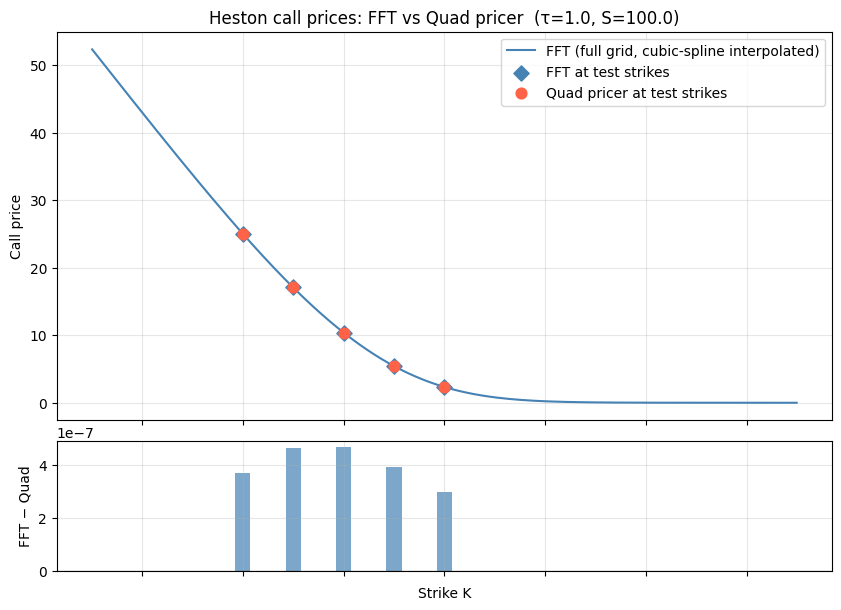

In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Restrict FFT curve to a sensible strike range ──────────────────────────
strikes = np.exp(log_strikes)
mask = (strikes > 50) & (strikes < 200) & (call_prices > 1e-4)

fig = plt.figure(figsize=(10, 7))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08)

# ── Top panel: price curves ────────────────────────────────────────────────
ax_top = fig.add_subplot(gs[0])

ax_top.plot(strikes[mask], call_prices[mask], color="steelblue", lw=1.5,
            label="FFT (full grid, cubic-spline interpolated)")
ax_top.scatter(test_strikes, fft_prices, s=60, zorder=5,
               color="steelblue", marker="D", label="FFT at test strikes")
ax_top.scatter(test_strikes, quad_prices, s=60, zorder=6,
               color="tomato", marker="o", label="Quad pricer at test strikes")

ax_top.set_ylabel("Call price")
ax_top.set_title(f"Heston call prices: FFT vs Quad pricer  (τ={tau}, S={S})")
ax_top.legend()
ax_top.set_xticklabels([])           # shared x-axis — hide labels on top panel
ax_top.grid(True, alpha=0.3)

# ── Bottom panel: absolute difference ─────────────────────────────────────
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

diffs = fft_prices - quad_prices
ax_bot.bar(test_strikes, diffs, width=3, color=["tomato" if d < 0 else "steelblue" for d in diffs],
           alpha=0.7)
ax_bot.axhline(0, color="black", lw=0.8)
ax_bot.set_xlabel("Strike K")
ax_bot.set_ylabel("FFT − Quad")
ax_bot.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax_bot.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
def heston_fft_iv_surface(strikes, maturities, S, r, v0, kappa, theta, xi, rho,
                           alpha=1.5, N=4096, eta=0.25):
    